# Clasificador de Vinos con KNN

## Descripción de las columnas
Cada fila representa un vino. Las columnas describen su composición química:

fixed acidity, volatile acidity, citric acid

residual sugar, chlorides

free sulfur dioxide, total sulfur dioxide

density, pH, sulphates, alcohol

La columna objetivo es label:

0 = Baja calidad

1 = Calidad media

2 = Alta calidad

## Carga de datos

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

In [36]:
df = pd.read_csv('/workspaces/IgnacioSabinoG-IntroML/data/raw/winequality-red.csv', sep= ';')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [38]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


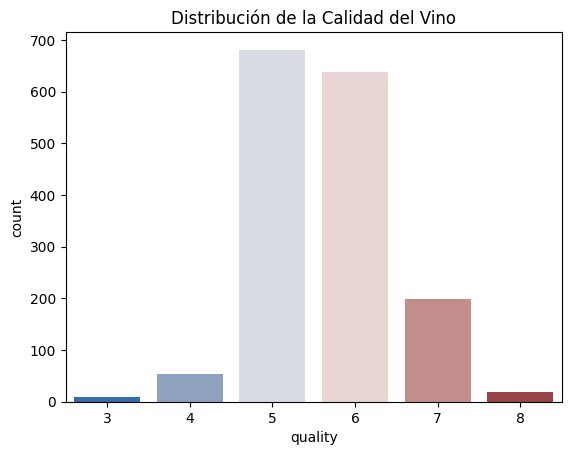

In [39]:
sns.countplot(x='quality', data=df, hue='quality', palette='vlag', legend=False)
plt.title('Distribución de la Calidad del Vino')
plt.show()

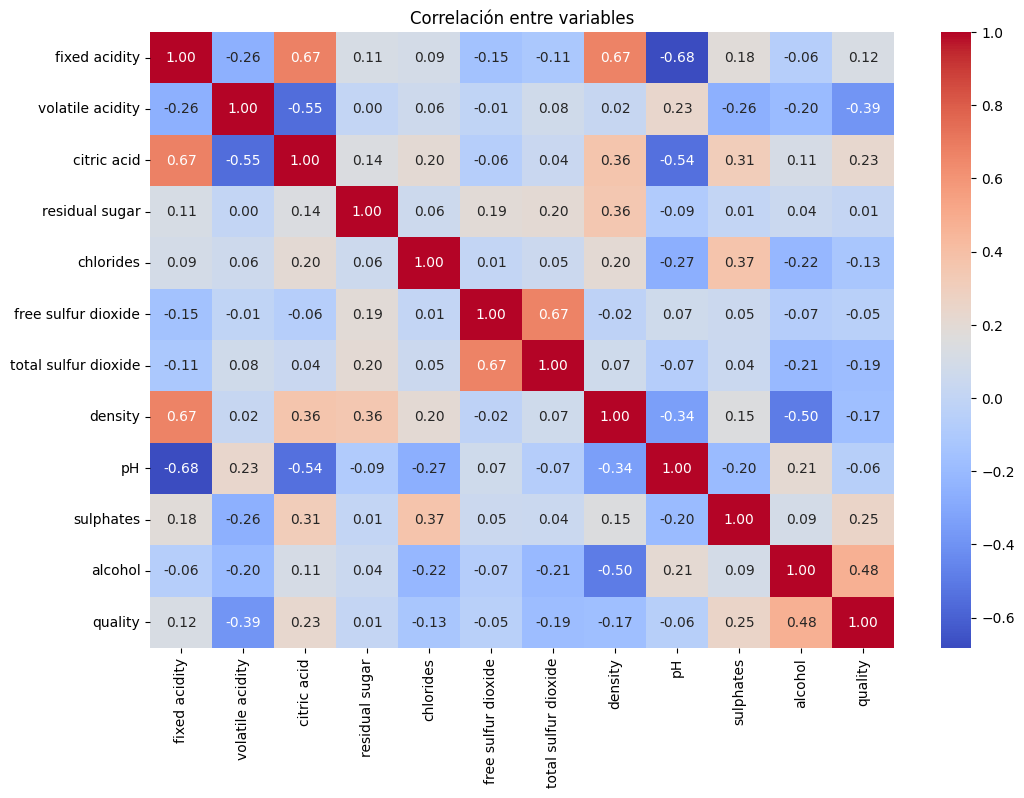

In [40]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlación entre variables')
plt.show()

Es muy importante en la calidad del vino el porcentaje de alcohol y la acidez volátil y en segundo lugar los sulfatos, el ácido cítrico y el dióxido de sulfuro.

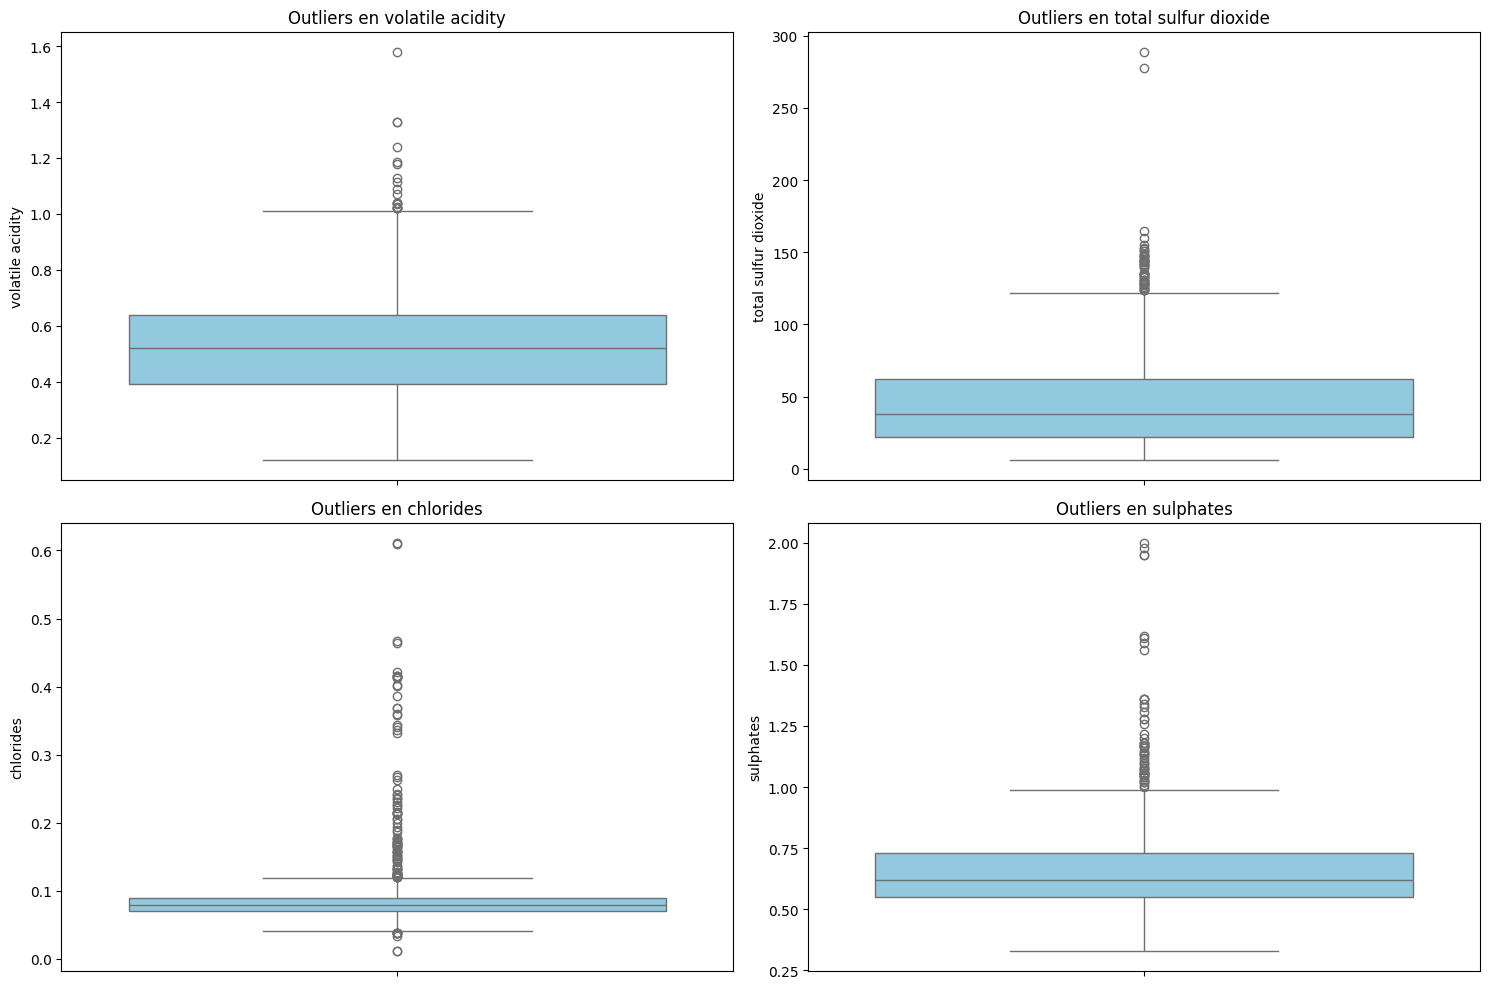

In [41]:
plt.figure(figsize=(15, 10))
cols = ['volatile acidity', 'total sulfur dioxide', 'chlorides', 'sulphates']
for i, col in enumerate(cols):
    plt.subplot(2, 2, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outliers en {col}')
plt.tight_layout()
plt.show()

## Preparación y escalado

In [42]:
X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ¡Paso vital para KNN!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Optimización de K (El bucle)

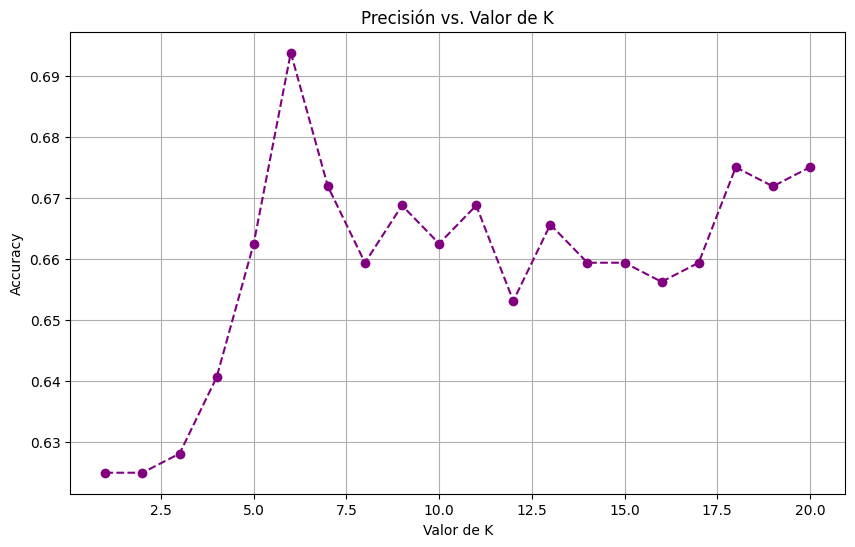

El mejor valor de k es: 6


In [43]:
accuracies = []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(X_train_scaled, y_train)
    accuracies.append(knn.score(X_test_scaled, y_test))

# Gráfica Visual
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o', linestyle='--', color='purple')
plt.title('Precisión vs. Valor de K')
plt.xlabel('Valor de K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# Elegimos el mejor k (el que tenga mayor accuracy)
best_k = k_range[np.argmax(accuracies)]
print(f"El mejor valor de k es: {best_k}")

## Eliminación de variables de baja correlación y mapeo de calidad

In [44]:
df_limpio = df.drop(columns=['residual sugar', 'free sulfur dioxide', 'pH', 'fixed acidity', 'chlorides'])

# Reemplazamos los valores de quality
# 3, 4 -> 0
# 5, 6 -> 1
# 7, 8 -> 2
mapeo_calidad = {3: 0, 4: 0, 5: 1, 6: 1, 7: 2, 8: 2}
df_limpio['quality'] = df_limpio['quality'].map(mapeo_calidad)

# Resultado
print(df_limpio.head())

   volatile acidity  citric acid  total sulfur dioxide  density  sulphates  \
0              0.70         0.00                  34.0   0.9978       0.56   
1              0.88         0.00                  67.0   0.9968       0.68   
2              0.76         0.04                  54.0   0.9970       0.65   
3              0.28         0.56                  60.0   0.9980       0.58   
4              0.70         0.00                  34.0   0.9978       0.56   

   alcohol  quality  
0      9.4        1  
1      9.8        1  
2      9.8        1  
3      9.8        1  
4      9.4        1  


In [45]:
X = df_limpio.drop('quality', axis=1)
y = df_limpio['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ¡Paso vital para KNN!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Debido al desbalance se usará weights='distance'

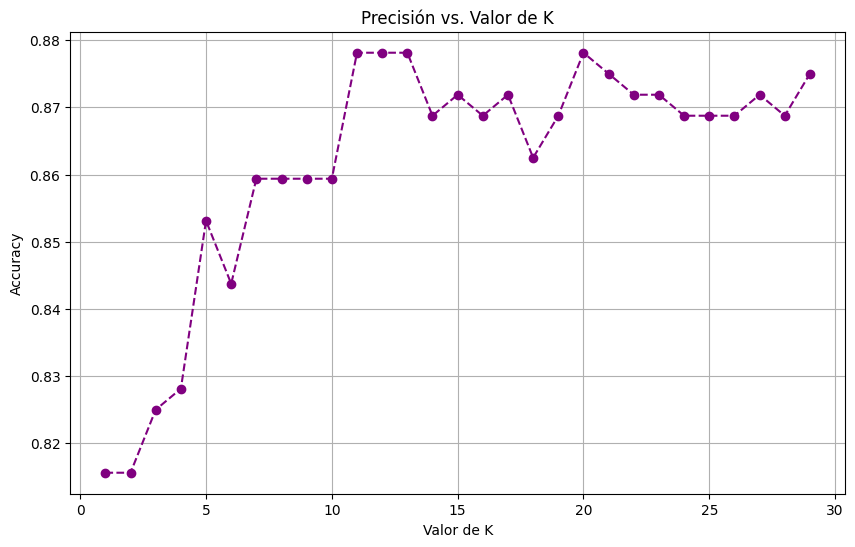

El mejor valor de k es: 11


In [46]:
accuracies = []
k_range = range(1, 30)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(X_train_scaled, y_train)
    accuracies.append(knn.score(X_test_scaled, y_test))

# Gráfica Visual
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o', linestyle='--', color='purple')
plt.title('Precisión vs. Valor de K')
plt.xlabel('Valor de K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# Elegimos el mejor k (el que tenga mayor accuracy)
best_k = k_range[np.argmax(accuracies)]
print(f"El mejor valor de k es: {best_k}")

Es notable cómo mejora con la eliminación de las variables que no tienen mucha correlación y reagrupamos las clases de quality.

Zona de estabilidad: Entre K 11 y 13 están los mejores resultados.

Se usará k=11 porque representa el codo de cambio.

------------------------------
RESULTADOS CON K = 11
------------------------------
Accuracy Score: 0.8781

Matriz de Confusión:
[[  0  12   1]
 [  0 252  12]
 [  0  14  29]]

Reporte de Clasificación:
              precision    recall  f1-score   support

    Baja (0)       0.00      0.00      0.00        13
   Media (1)       0.91      0.95      0.93       264
    Alta (2)       0.69      0.67      0.68        43

    accuracy                           0.88       320
   macro avg       0.53      0.54      0.54       320
weighted avg       0.84      0.88      0.86       320



/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


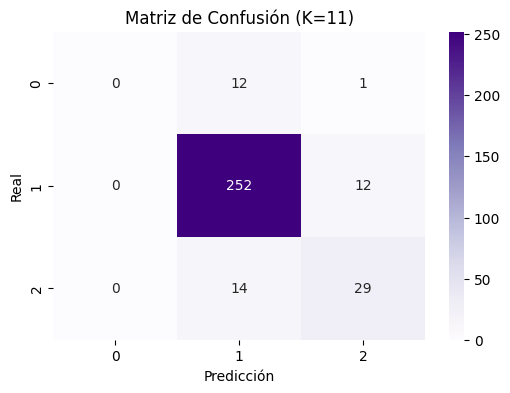

In [47]:
from sklearn.metrics import confusion_matrix

# 1. Entrenamos el modelo final con el mejor k encontrado
knn_final = KNeighborsClassifier(n_neighbors=11, weights='distance')
knn_final.fit(X_train_scaled, y_train)

# 2. Realizamos las predicciones sobre el set de prueba
y_pred = knn_final.predict(X_test_scaled)

# 3. Generamos y mostramos las métricas
print("-" * 30)
print(f"RESULTADOS CON K = {11}")
print("-" * 30)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['Baja (0)', 'Media (1)', 'Alta (2)']))

# Opcional: Visualizar la matriz de confusión más clara
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples', 
            xticklabels=['0','1','2'], yticklabels=['0','1','2'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title(f'Matriz de Confusión (K={11})')
plt.show()

## La función de predicción "Sommelier IA"

In [48]:
X = df_limpio.drop('quality', axis=1)
y = df_limpio['quality']

# 2. Re-entrenamos el escalador y el modelo final con k=6
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model_final = KNeighborsClassifier(n_neighbors=6, weights='distance')
model_final.fit(X_scaled, y)

def predict_wine_quality(features):
    features_df = pd.DataFrame([features], columns=X_train.columns)
    features_scaled = scaler.transform(features_df)  # scaler ya entrenado antes
    prediction = knn_final.predict(features_scaled)[0]  # modelo ya entrenado
    
    if prediction == 2:
        return "¡Espectacular! Este vino es una joya. 🥂"
    elif prediction == 1:
        return "Un vino de calidad media, ideal para diario. 🍷"
    else:
        return "Mmm... quizás mejor para cocinar. 🍳"


test_wine = [0.7, 0.0, 34.0, 0.9978, 0.56, 9.4]
print("\n--- PRUEBA DE PREDICCIÓN ---")
print(predict_wine_quality(test_wine))



--- PRUEBA DE PREDICCIÓN ---
Un vino de calidad media, ideal para diario. 🍷


# Guardado del modelo

In [49]:
joblib.dump(knn_final, "/workspaces/IgnacioSabinoG-IntroML/src/knn_vinos.pkl")
joblib.dump(scaler, "/workspaces/IgnacioSabinoG-IntroML/src/scaler_vinos.pkl")
print("\n✅ Modelo y scaler guardados correctamente.")


✅ Modelo y scaler guardados correctamente.
